<a href="https://colab.research.google.com/github/NethsanduKumarasinghe/EN3160_Assignment_01/blob/main/EN3160_Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering

**Name:** Kumarasinghe M. N.  
**Index:** 230355X

In [6]:
from google.colab import files

uploaded = files.upload()

Saving images.zip to images.zip


In [7]:
import zipfile

with zipfile.ZipFile("images.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Question 1

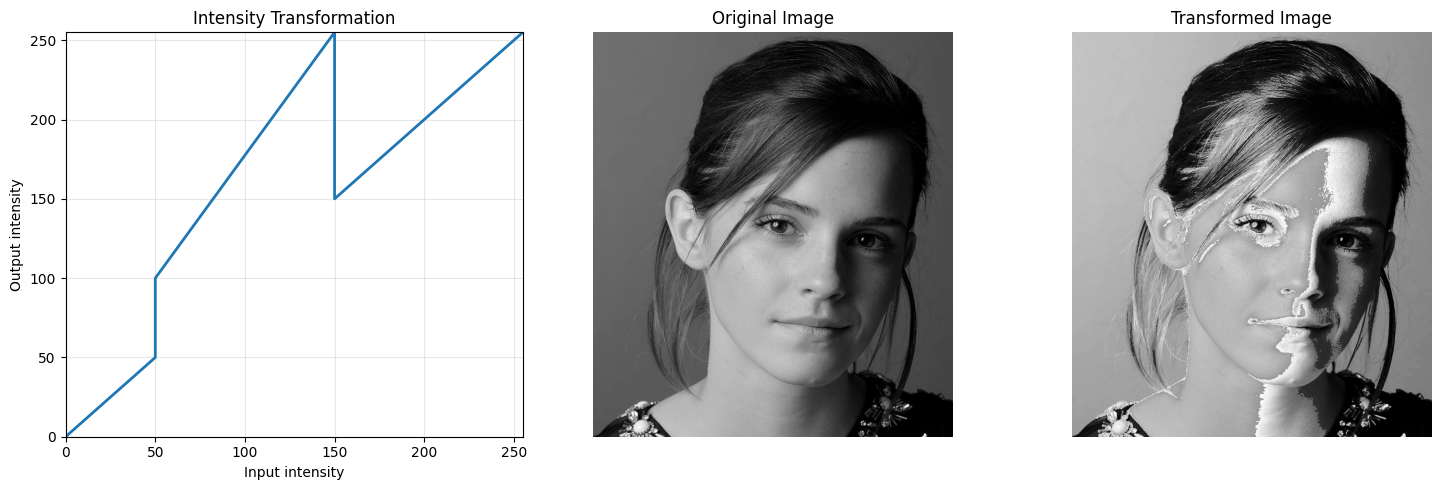

In [8]:
image_path = "/content/images/q1.jpeg"

im = cv.imread(image_path, cv.IMREAD_GRAYSCALE)


def intensity_transform(im, breakpoints):
    output = np.zeros_like(im, dtype=np.float32)

    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        if x1 == x2:
            continue

        mask = (im >= x1) & (im < x2)

        output[mask] = y1 + (im[mask] - x1) * (y2 - y1) / (x2 - x1)

    output[im >= breakpoints[-1, 0]] = breakpoints[-1, 1]

    return np.clip(output, 0, 255).astype(np.uint8)


breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50,100],
    [150, 255],
    [150,150],
    [255, 255]
])

transformed = intensity_transform(im, breakpoints)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
x_plot = breakpoints[:, 0]
y_plot = breakpoints[:, 1]
plt.plot(x_plot, y_plot, linewidth=2)
plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Intensity Transformation")

plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(transformed, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()

plt.show()

#### Visually pleasing image with different breakpoints

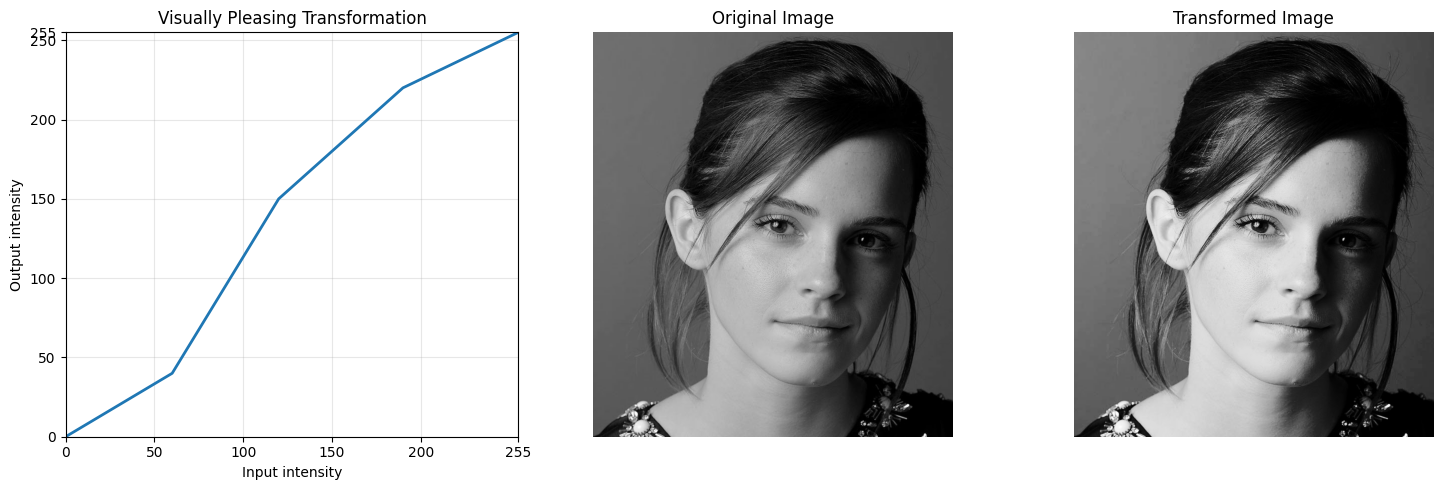

In [9]:
breakpoints_pleasing = np.array([
    [0, 0],
    [60, 40],
    [120, 150],
    [190, 220],
    [255, 255]
])

transformed_pleasing = intensity_transform(im, breakpoints_pleasing)

x_plot = breakpoints_pleasing[:, 0]
y_plot = breakpoints_pleasing[:, 1]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x_plot, y_plot, linewidth=2)
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xticks([0, 50, 100, 150, 200, 255])
plt.yticks([0, 50, 100, 150, 200, 250, 255])
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Visually Pleasing Transformation")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(transformed_pleasing, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

## Question 2

#### a) Accentuate white matter

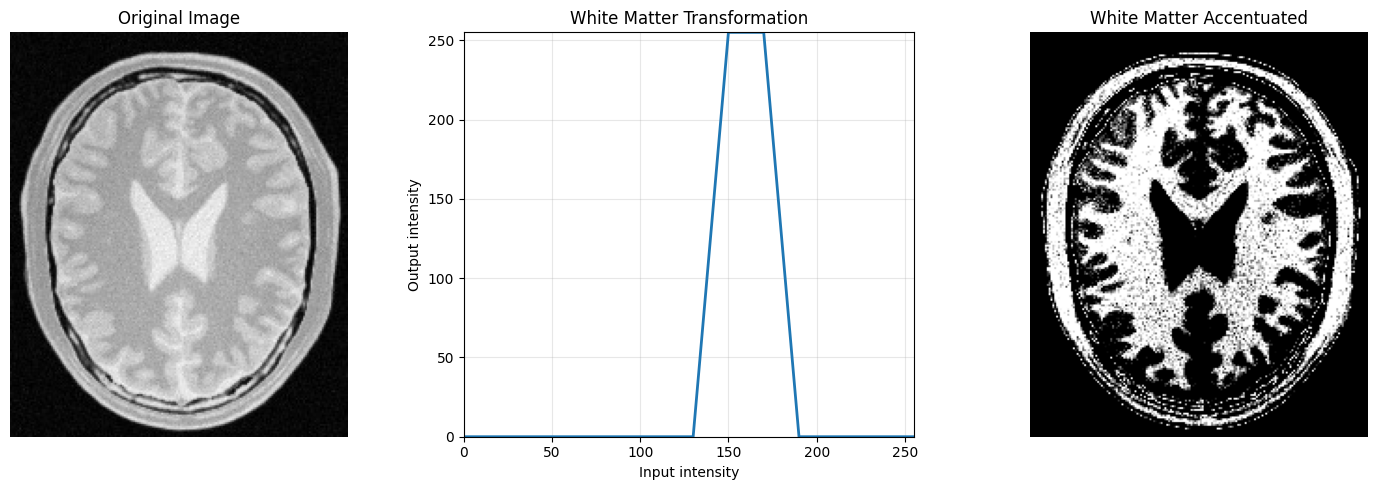

In [31]:
image_path = "/content/images/q2.jpeg"

im = cv.imread(image_path, cv.IMREAD_GRAYSCALE)


white_breakpoints = np.array([
    [0, 0],
    [130, 0],

    [150,255],
    [170,255],
    [190,0],
    [255, 0]
])

white_matter = intensity_transform(im, white_breakpoints)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.plot(white_breakpoints[:, 0], white_breakpoints[:, 1], linewidth=2)
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("White Matter Transformation")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.imshow(white_matter, cmap="gray", vmin=0, vmax=255)
plt.title("White Matter Accentuated")
plt.axis("off")

plt.tight_layout()

plt.show()

#### b) Accentuate gray matter

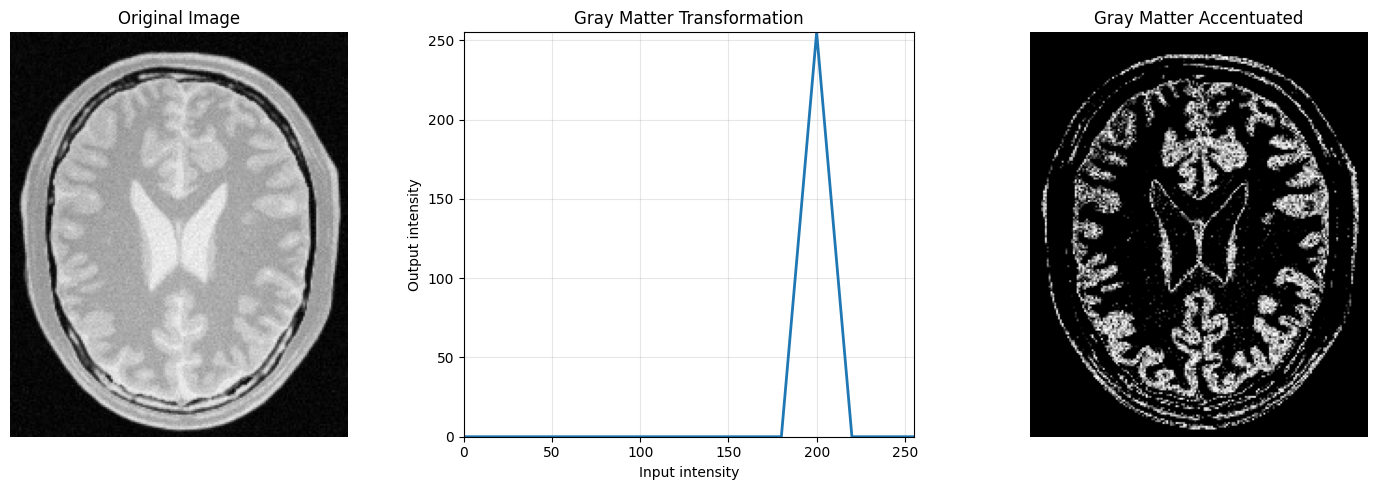

In [29]:
gray_breakpoints = np.array([
    [0, 0],
    [180, 0],
    [200, 255],
    [220, 0],
    [255, 0]
])

gray_matter = intensity_transform(im, gray_breakpoints)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.plot(gray_breakpoints[:, 0], gray_breakpoints[:, 1], linewidth=2)
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Gray Matter Transformation")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.imshow(gray_matter, cmap="gray", vmin=0, vmax=255)
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()

## Question 3

#### a)

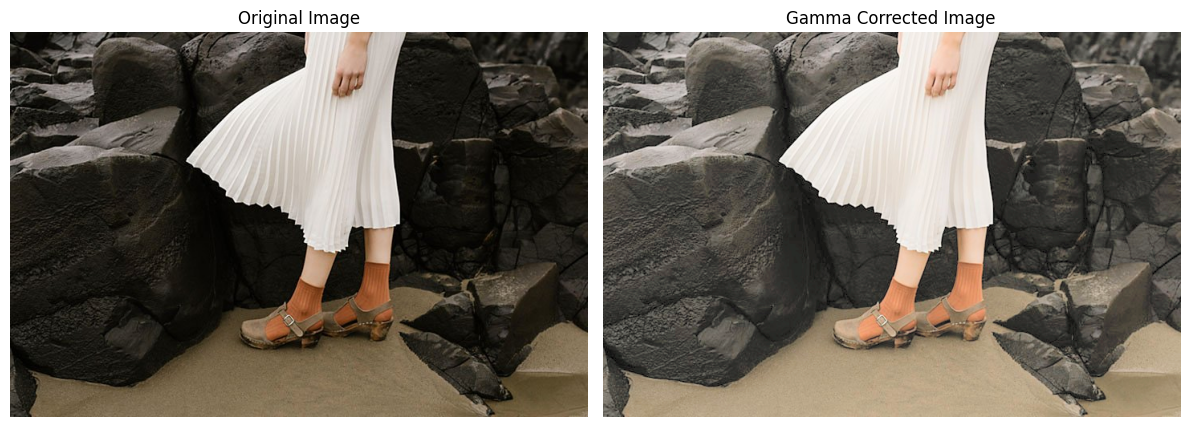

In [32]:
image_path = "/content/images/q3.jpeg"

im = cv.imread(image_path)

lab = cv.cvtColor(im, cv.COLOR_BGR2LAB)

L, a, b = cv.split(lab)

gamma = 0.5

L_normalized = L / 255.0
L_corrected = np.power(L_normalized, gamma)
L_corrected = np.uint8(L_corrected * 255)

lab_corrected = cv.merge([L_corrected, a, b])

corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(corrected, cv.COLOR_BGR2RGB))
plt.title("Gamma Corrected Image")
plt.axis("off")

plt.tight_layout()
plt.show()

#### b)

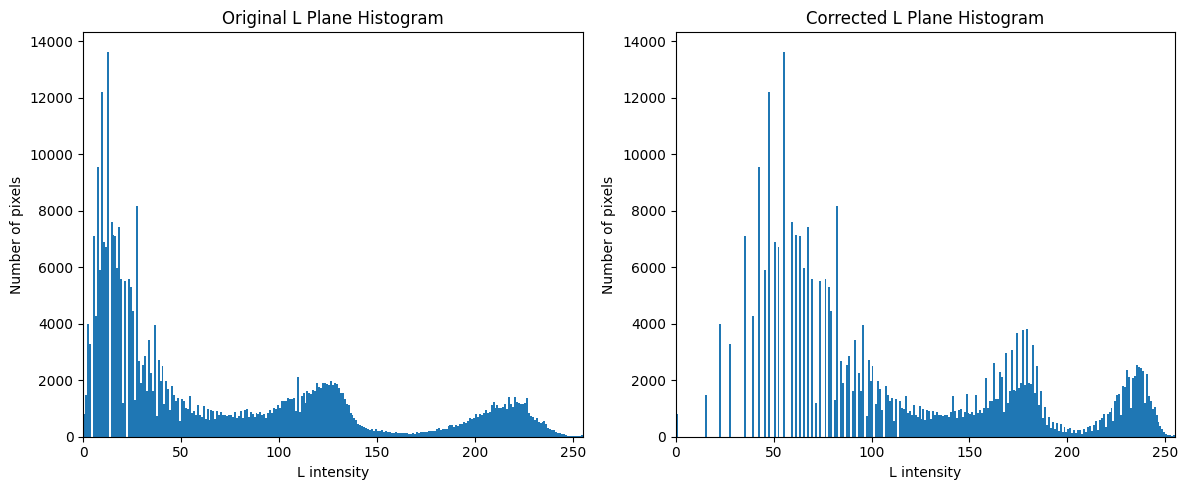

In [33]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(L.ravel(), bins=256, range=(0, 256))
plt.xlabel("L intensity")
plt.ylabel("Number of pixels")
plt.title("Original L Plane Histogram")
plt.xlim(0, 255)

plt.subplot(1, 2, 2)
plt.hist(L_corrected.ravel(), bins=256, range=(0, 256))
plt.xlabel("L intensity")
plt.ylabel("Number of pixels")
plt.title("Corrected L Plane Histogram")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

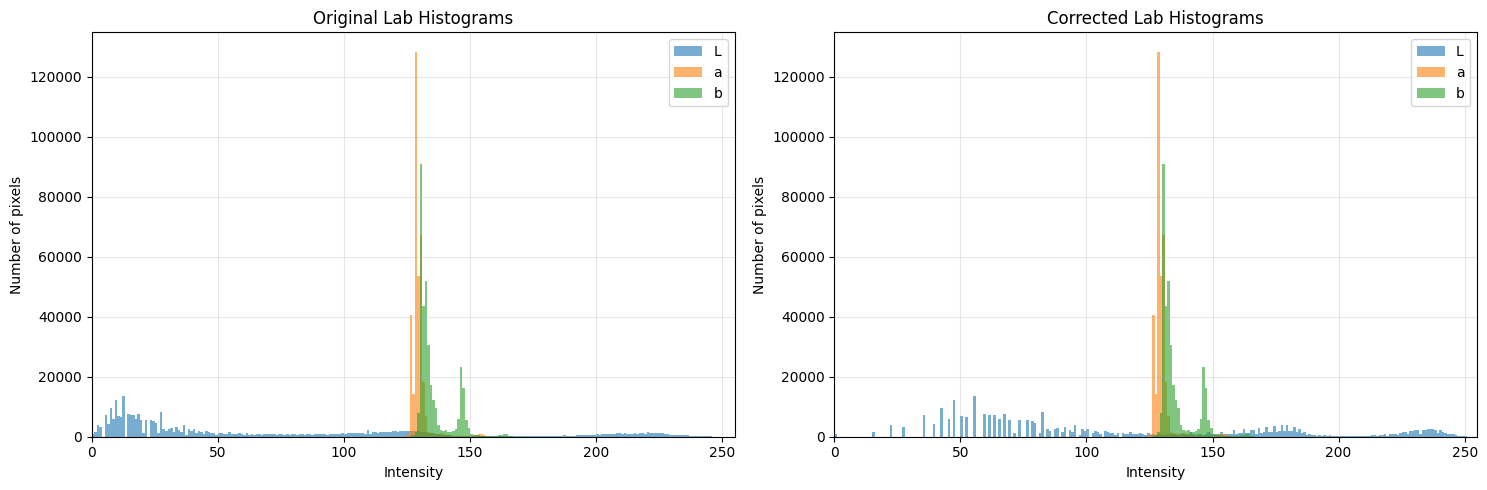

In [34]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(L.ravel(), bins=256, range=(0, 256), alpha=0.6, label="L")
plt.hist(a.ravel(), bins=256, range=(0, 256), alpha=0.6, label="a")
plt.hist(b.ravel(), bins=256, range=(0, 256), alpha=0.6, label="b")
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Original Lab Histograms")
plt.xlim(0, 255)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(L_corrected.ravel(), bins=256, range=(0, 256), alpha=0.6, label="L")
plt.hist(a.ravel(), bins=256, range=(0, 256), alpha=0.6, label="a")
plt.hist(b.ravel(), bins=256, range=(0, 256), alpha=0.6, label="b")
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Corrected Lab Histograms")
plt.xlim(0, 255)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Question 4

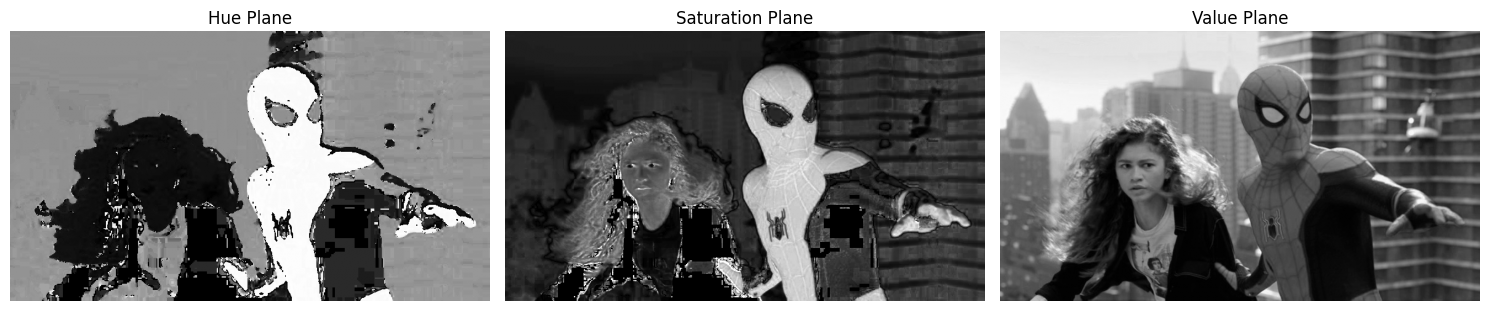

In [38]:
image_path = "/content/images/q4.jpeg"
im = cv.imread(image_path)
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)

hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue Plane")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation Plane")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value Plane")
plt.axis("off")

plt.tight_layout()
plt.show()

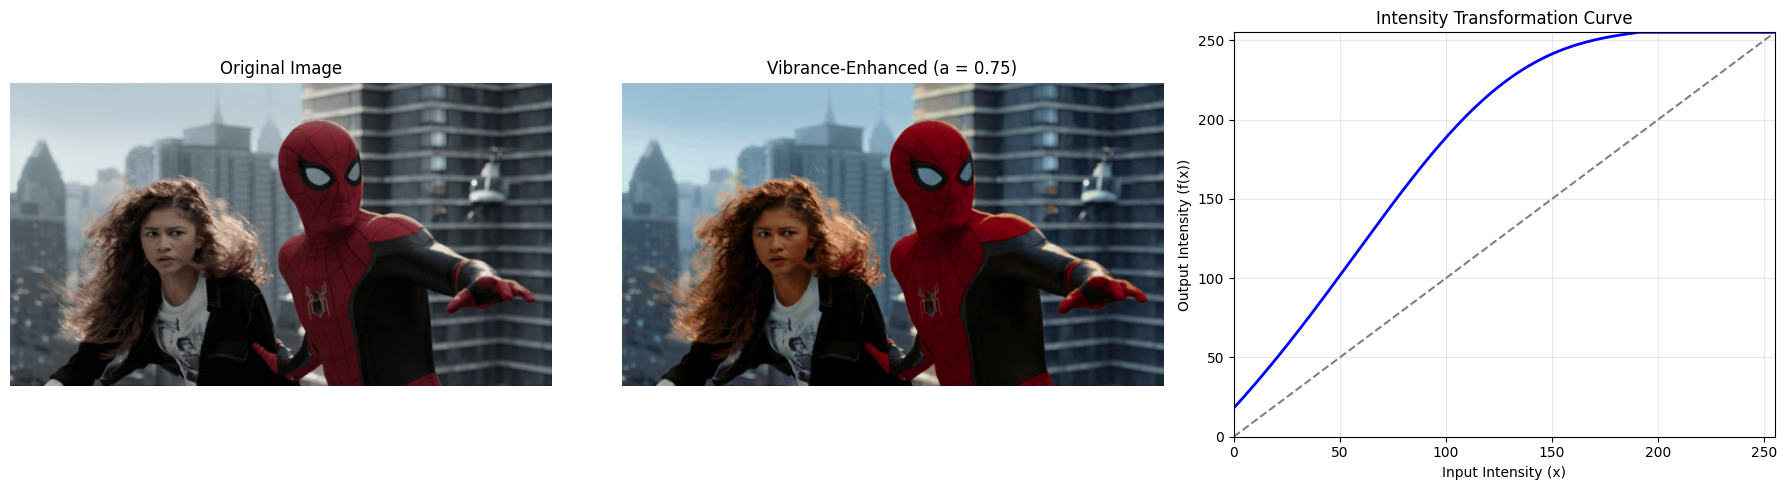

In [47]:
x = S.astype(np.float64)
sigma = 70.0
a = 0.75

exponent = -((x - 128.0)**2) / (2.0 * sigma**2)
modifier = a * 128.0 * np.exp(exponent)
S_enhanced = np.clip(x + modifier, 0, 255).astype(np.uint8)

hsv_enhanced = cv.merge([H, S_enhanced, V])
im_vibrant = cv.cvtColor(hsv_enhanced, cv.COLOR_HSV2RGB)

x_vals = np.arange(0, 256)
y_vals = np.clip(x_vals + a * 128.0 * np.exp(-((x_vals - 128.0)**2) / (2.0 * sigma**2)), 0, 255)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(im_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(im_vibrant)
plt.title(f"Vibrance-Enhanced (a = {a})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.plot(x_vals, y_vals, color='blue', linewidth=2)
plt.plot(x_vals, x_vals, color='gray', linestyle='--')
plt.title("Intensity Transformation Curve")
plt.xlabel("Input Intensity (x)")
plt.ylabel("Output Intensity (f(x))")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### (c) Parameter Selection

**Reported Value:** `a = 0.75`

**Justification:** Setting `a = 0.75` provides a visually pleasing enhancement to the image's vibrance. This value is high enough to significantly boost the mid-tone saturations (making the reds and blues of the suit pop) while remaining low enough to prevent unnatural oversaturation or severe color clipping at the high end of the spectrum.

## Question 5

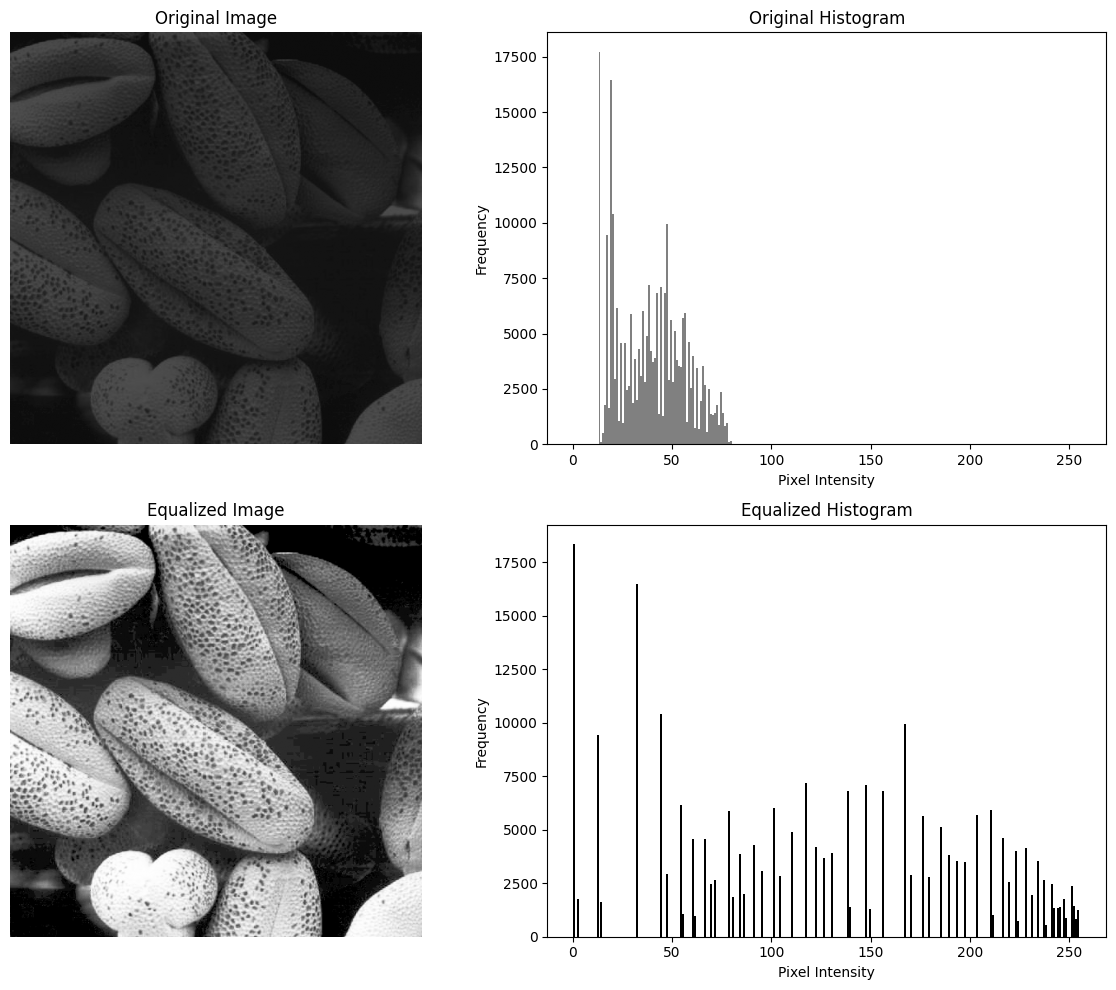

In [51]:
def custom_histogram_equalization(img):
    hist, bins = np.histogram(img.flatten(), 256, [0, 256])

    cdf = hist.cumsum()

    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_normalized = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    cdf_final = np.ma.filled(cdf_normalized, 0).astype(np.uint8)

    img_equalized = cdf_final[img]

    return img_equalized

image_path = "/content/images/q5.tif"
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

img_eq = custom_histogram_equalization(img)

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.hist(img.flatten(), bins=256, range=[0, 256], color='gray')
plt.title("Original Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(2, 2, 3)
plt.imshow(img_eq, cmap='gray', vmin=0, vmax=255)
plt.title("Equalized Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.hist(img_eq.flatten(), bins=256, range=[0, 256], color='black')
plt.title("Equalized Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Question 6

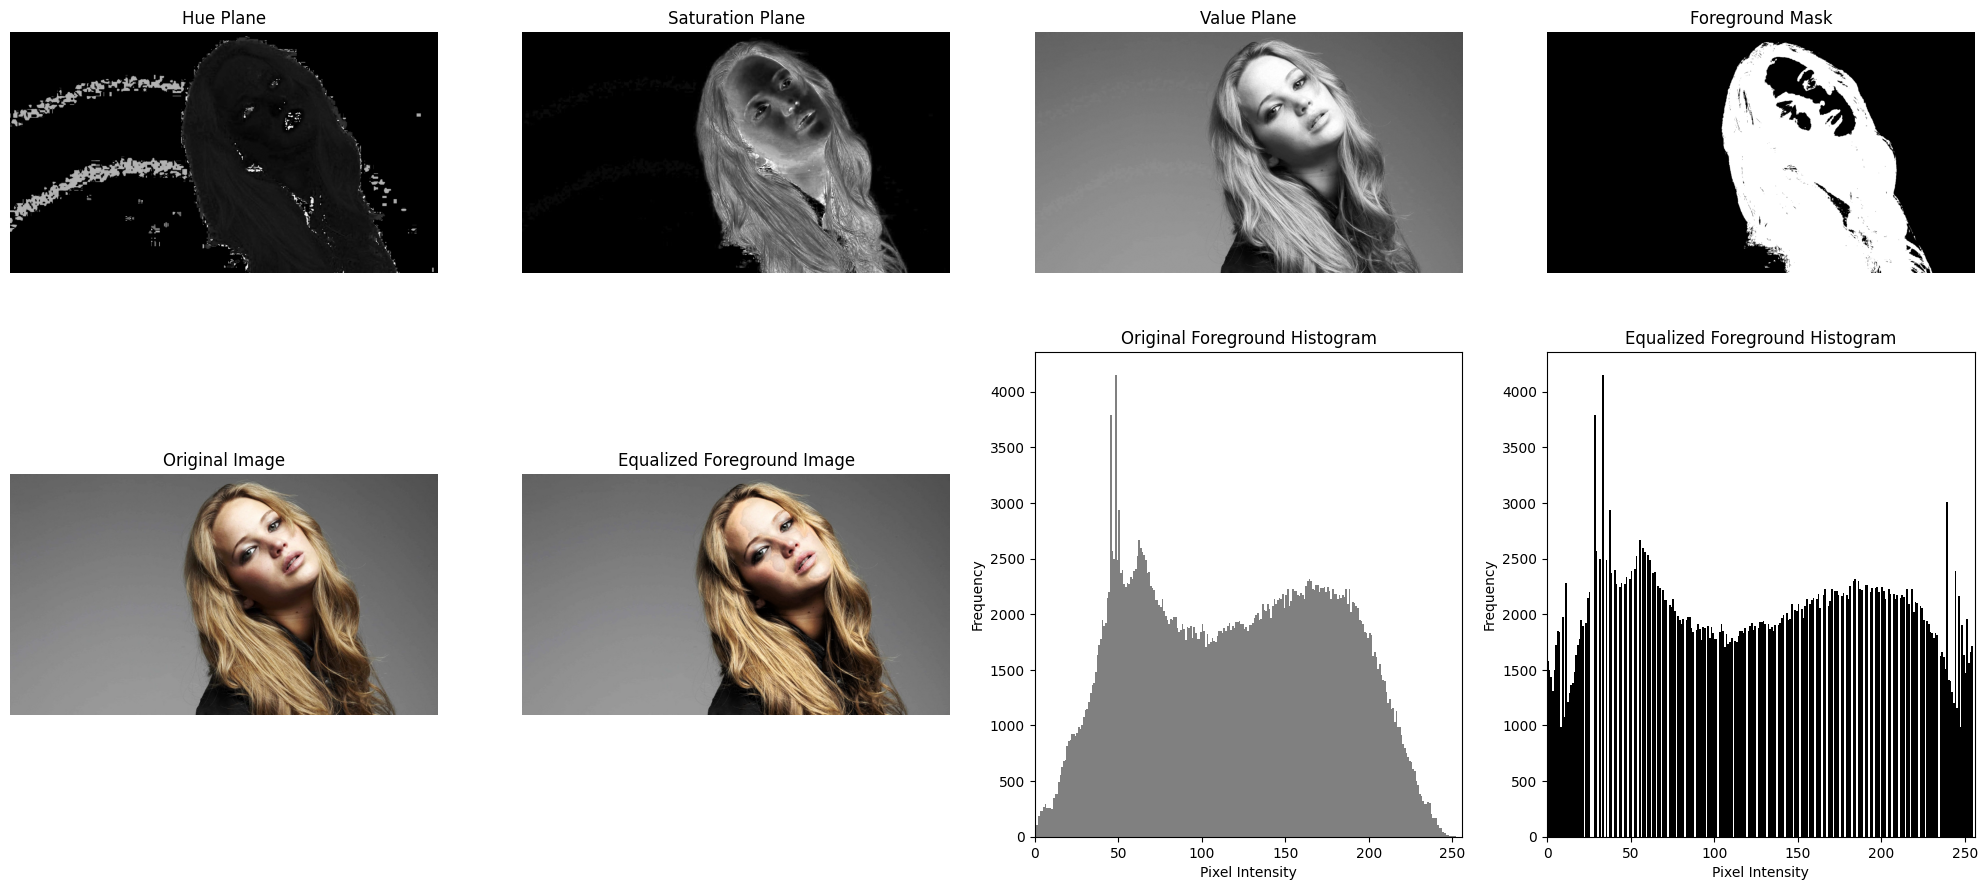

In [54]:
image_path = "/content/images/q6.jpeg"
img = cv.imread(image_path)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

_, mask = cv.threshold(S, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

V_fg = cv.bitwise_and(V, V, mask=mask)
fg_pixels = V_fg[mask == 255]

hist, _ = np.histogram(fg_pixels, 256, [0, 256])

cdf = np.cumsum(hist)

cdf_masked = np.ma.masked_equal(cdf, 0)
cdf_normalized = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
cdf_final = np.ma.filled(cdf_normalized, 0).astype(np.uint8)

V_eq_full = cdf_final[V]
V_eq_fg = cv.bitwise_and(V_eq_full, V_eq_full, mask=mask)
eq_fg_pixels = V_eq_fg[mask == 255]

mask_inv = cv.bitwise_not(mask)
V_bg = cv.bitwise_and(V, V, mask=mask_inv)

V_final = cv.add(V_eq_fg, V_bg)

hsv_final = cv.merge([H, S, V_final])
img_final = cv.cvtColor(hsv_final, cv.COLOR_HSV2RGB)

plt.figure(figsize=(20, 10))

plt.subplot(2, 4, 1)
plt.imshow(H, cmap='gray')
plt.title("Hue Plane")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(S, cmap='gray')
plt.title("Saturation Plane")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(V, cmap='gray')
plt.title("Value Plane")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(mask, cmap='gray')
plt.title("Foreground Mask")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(img_final)
plt.title("Equalized Foreground Image")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.hist(fg_pixels, bins=256, range=[0, 256], color='gray')
plt.title("Original Foreground Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.subplot(2, 4, 8)
plt.hist(eq_fg_pixels, bins=256, range=[0, 256], color='black')
plt.title("Equalized Foreground Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()